In [1]:
import sys
sys.path.insert(0, '/home/phil/Dev/Python/Single Cell/scanpy')
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
import tarfile
from urllib.request import urlopen, Request
url = "https://cf.10xgenomics.com/samples/cell-exp/1.1.0/pbmc3k/pbmc3k_filtered_gene_bc_matrices.tar.gz"
ua = "Mozilla/5.0 (Android; Mobile; rv:40.0) Gecko/40.0 Firefox/40.0"
req = Request(url, data=None, headers={'User-Agent': ua})
path_data = Path("data")
path_matrices = path_data / "filtered_gene_bc_matrices"
if not path_matrices.is_dir():
    with urlopen(req) as r:
        with tarfile.open(fileobj=r, mode='r|gz') as archive:
            archive.extractall(path_data)

In [4]:
adata = sc.read_10x_mtx(path_matrices / "hg19", var_names='gene_symbols', cache=True)

# preprocess

In [5]:
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

In [6]:
mito_genes = adata.var_names.str.startswith('MT-')
adata.obs['percent_mito'] = np.sum(adata[:, mito_genes].X, axis=1).A1 / np.sum(adata.X, axis=1).A1
adata.obs['n_counts'] = adata.X.sum(axis=1).A1

In [7]:
adata = adata[adata.obs.n_genes < 2500, :]
adata = adata[adata.obs.percent_mito < 0.05, :]

In [8]:
sc.pp.normalize_total(adata, target_sum=1e4)

/home/phil/Dev/Python/Single Cell/scanpy/scanpy/preprocessing/_normalization.py:170: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [9]:
sc.pp.log1p(adata)

In [10]:
adata.raw = adata

In [11]:
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
adata = adata[:, adata.var['highly_variable']]

In [12]:
sc.pp.regress_out(adata, ['n_counts', 'percent_mito'])

In [13]:
sc.pp.scale(adata, max_value=10)

In [14]:
sc.tl.pca(adata, svd_solver='arpack')

In [15]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)

/home/phil/Dokumente/Diss/dissertation/.venv/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# analyze

In [16]:
sc.tl.umap(adata)

In [17]:
sc.tl.leiden(adata)

In [18]:
marker_genes = [
    'IL7R', 'CD79A', 'MS4A1', 'CD8A', 'CD8B', 'LYZ',
    'CD14', 'LGALS3', 'S100A8', 'GNLY', 'NKG7', 'KLRB1',  
    'FCGR3A', 'MS4A7', 'FCER1A', 'CST3', 'PPBP',
]

In [19]:
sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon')

In [20]:
cluster_markers = {
    'CD4 T': {'IL7R'},
    'CD14+\nMonocytes': {'CD14', 'LYZ'},
    'B': {'MS4A1'},
    'CD8 T': {'CD8A'},
    'NK': {'GNLY', 'NKG7'},
    'FCGR3A+\nMonocytes': {'FCGR3A', 'MS4A7'},
    'Dendritic': {'FCER1A', 'CST3'},
    'Mega-\nkaryocytes': {'PPBP'},
}
marker_matches = sc.tl.marker_gene_overlap(adata, cluster_markers)

In [21]:
adata.rename_categories('leiden', marker_matches.idxmax().pipe(lambda s: s + (s.groupby(s).cumcount() - 1).astype(str).replace('-1', '')))

/home/phil/Dokumente/Diss/dissertation/.venv/lib/python3.10/site-packages/anndata/_core/anndata.py:1160: FutureWarning: The `inplace` parameter in pandas.Categorical.rename_categories is deprecated and will be removed in a future version. Removing unused categories will always return a new Categorical object.
  self.obs[key].cat.rename_categories(categories, inplace=True)


In [22]:
sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon')

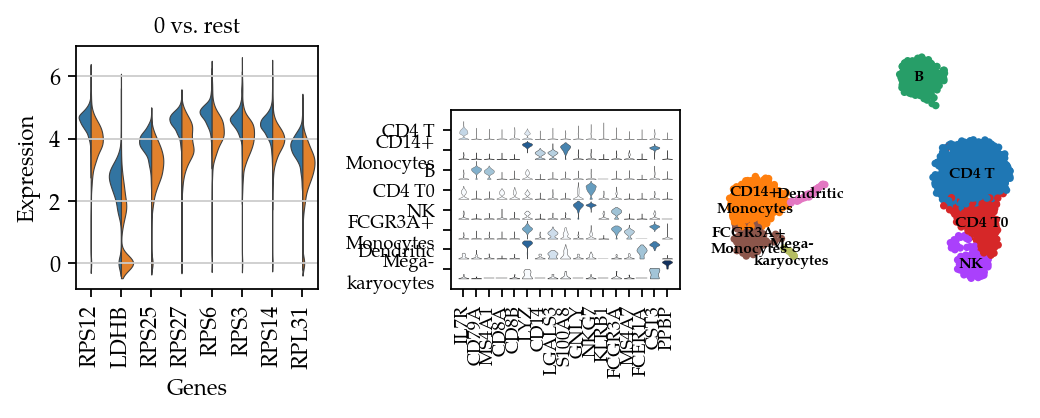

In [32]:
sc.settings.set_figure_params(fontsize=10)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['font.serif'] = ['Palatino', 'Palatino Linotype', 'TeX Gyre Pagella']
plt.rcParams['lines.linewidth'] = .5

fig = plt.figure(figsize=(7.6, 2))
gs = fig.add_gridspec(1, 2, width_ratios=[2, 1], wspace=0.05)
gssub = gs[0].subgridspec(1, 2, wspace=.55)
axs = [fig.add_subplot(gssub[0]), fig.add_subplot(gssub[1]), fig.add_subplot(gs[1])]

sc.pl.rank_genes_groups_violin(adata, groups=adata.obs['leiden'].cat.categories[0], n_genes=8, strip=False, ax=axs[0], show=False)
vp = sc.pl.stacked_violin(adata, marker_genes, groupby='leiden', rotation=90, ax=axs[1], show=False, return_fig=True)
vp.legends_width = 0
vp.make_figure()
sc.pl.umap(adata, color='leiden', legend_loc='on data', legend_fontsize='x-small', title='', frameon=False, ax=axs[2], show=False)

axs[0].set_title('0 vs. rest')
axs[0].set_xlabel('Genes')
axs[0].set_ylabel('Expression')
fig.savefig('scanpy.pdf', bbox_inches='tight')